In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

In [2]:
import os
print(os.getcwd())

c:\Users\Ramakrishna\OneDrive\Desktop\mutual_fund_analysis\notebooks


In [4]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current folder:
c:\Users\Ramakrishna\OneDrive\Desktop\mutual_fund_analysis\notebooks

Files in current folder:
['day1_data_ingestion.ipynb', 'day2_data_cleaning.ipynb', 'EDA_Analysis.ipynb']


In [5]:
import os

for root, dirs, files in os.walk("../.."):
    for file in files:
        if "nav_history" in file.lower():
            print(os.path.join(root, file))

../..\ML Project\Bluestock_MF_Datasets\02_nav_history.csv
../..\mutual_fund_analysis\data\processed\nav_history_clean.csv
../..\mutual_fund_analysis\data\raw\02_nav_history.csv


In [6]:
import pandas as pd

nav_history = pd.read_csv(
    r"C:\Users\Ramakrishna\OneDrive\Desktop\mutual_fund_analysis\data\processed\nav_history_clean.csv"
)

print(nav_history.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [7]:
BASE = r"C:\Users\Ramakrishna\OneDrive\Desktop\mutual_fund_analysis\data\processed"

fund_master = pd.read_csv(f"{BASE}\\fund_master_clean.csv")
nav_history = pd.read_csv(f"{BASE}\\nav_history_clean.csv")
aum = pd.read_csv(f"{BASE}\\aum_clean.csv")
sip = pd.read_csv(f"{BASE}\\sip_clean.csv")
category = pd.read_csv(f"{BASE}\\category_clean.csv")
folios = pd.read_csv(f"{BASE}\\folios_clean.csv")
performance = pd.read_csv(f"{BASE}\\scheme_performance_clean.csv")
transactions = pd.read_csv(f"{BASE}\\investor_transactions_clean.csv")
holdings = pd.read_csv(f"{BASE}\\holdings_clean.csv")
benchmark = pd.read_csv(f"{BASE}\\benchmark_clean.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [8]:
print(nav_history.columns)
print(aum.columns)
print(sip.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [9]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [10]:
import plotly.express as px

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    opacity=0.2
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Correction",
    opacity=0.2
)

fig.show()

In [15]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

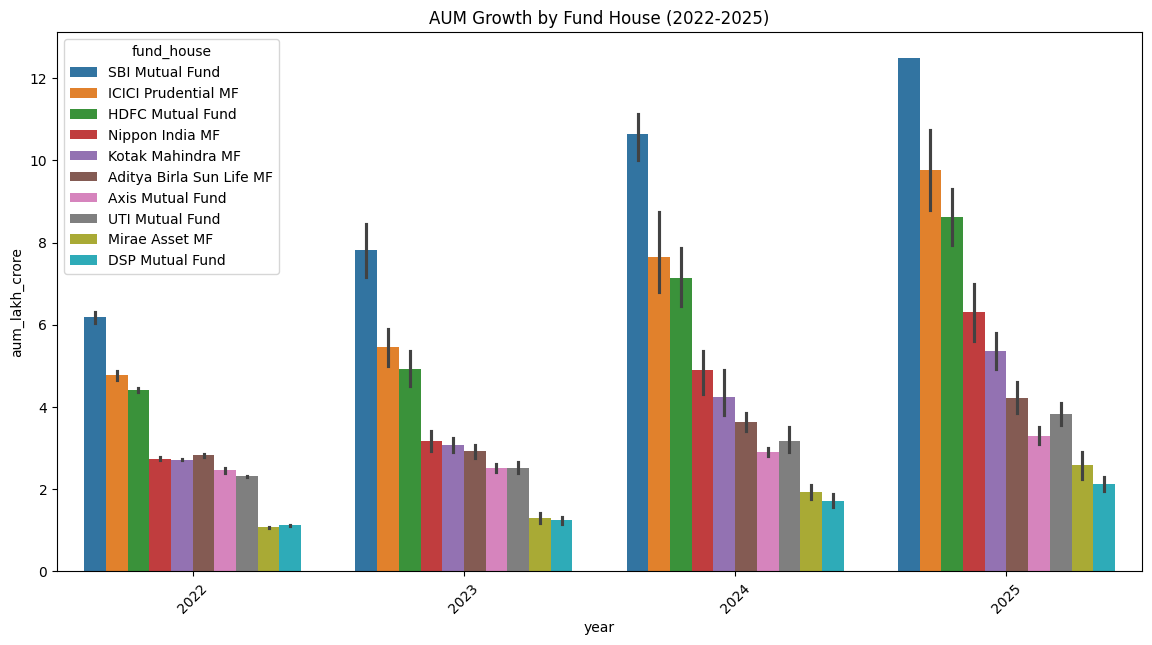

In [16]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xticks(rotation=45)

plt.show()

In [17]:
plt.savefig("../reports/aum_growth.png")

<Figure size 640x480 with 0 Axes>

In [18]:
sip["month"] = pd.to_datetime(sip["month"])

In [19]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x=sip["month"].iloc[-1],
    y=sip["sip_inflow_crore"].max(),
    text="₹31,002 Cr All-Time High",
    showarrow=True
)

fig.show()

In [25]:
print(category.columns)
print(transactions.columns)
print(folios.columns)
print(holdings.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


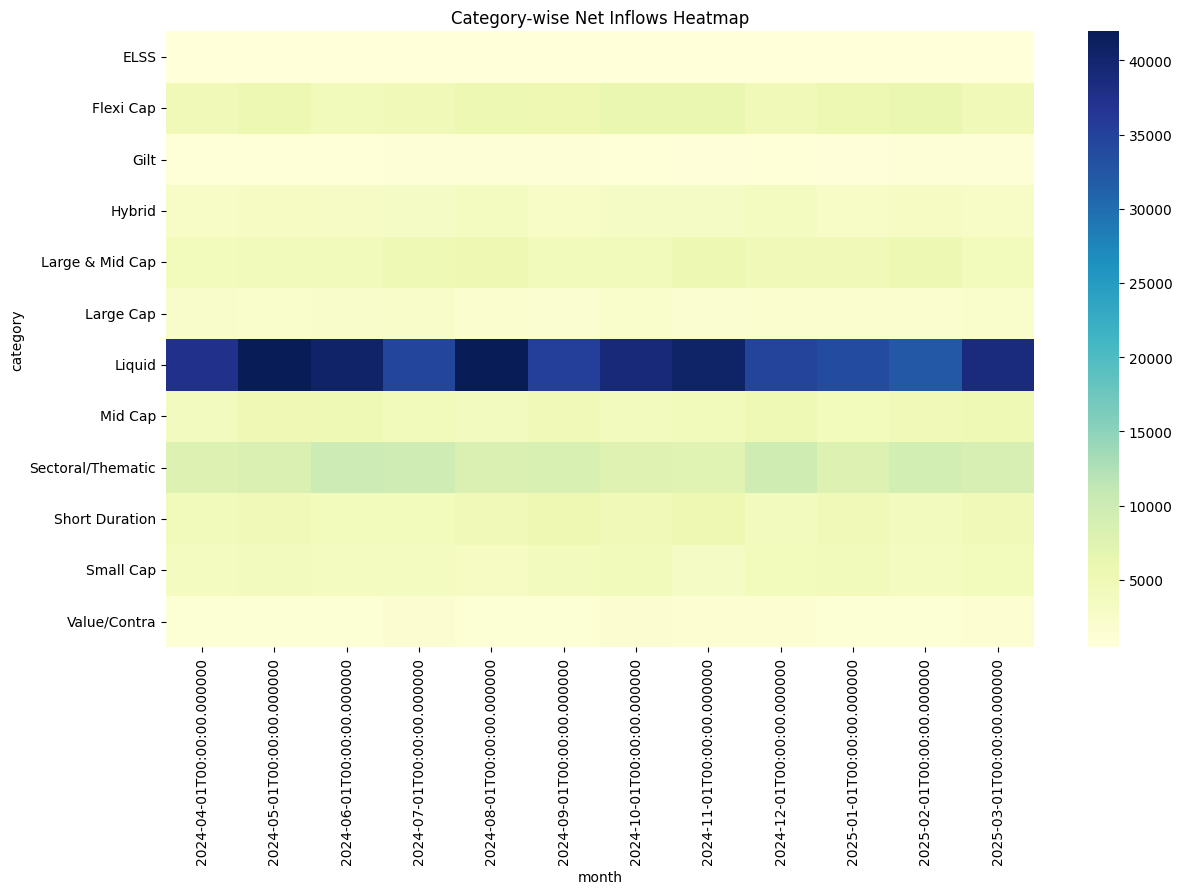

In [26]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows Heatmap")
plt.show()

In [27]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

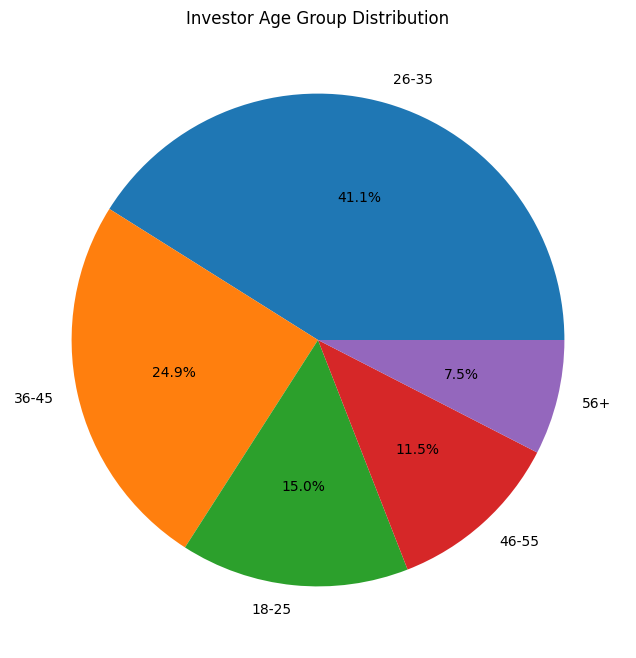

In [28]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.show()

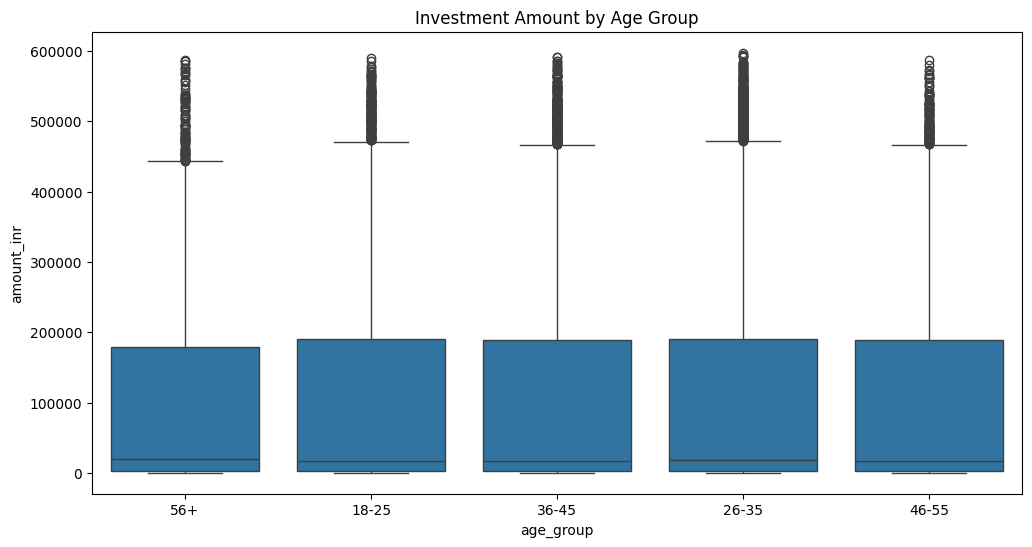

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.show()

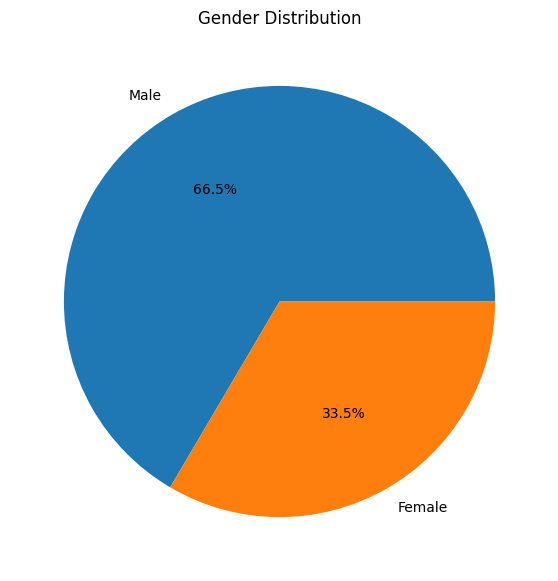

In [30]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()

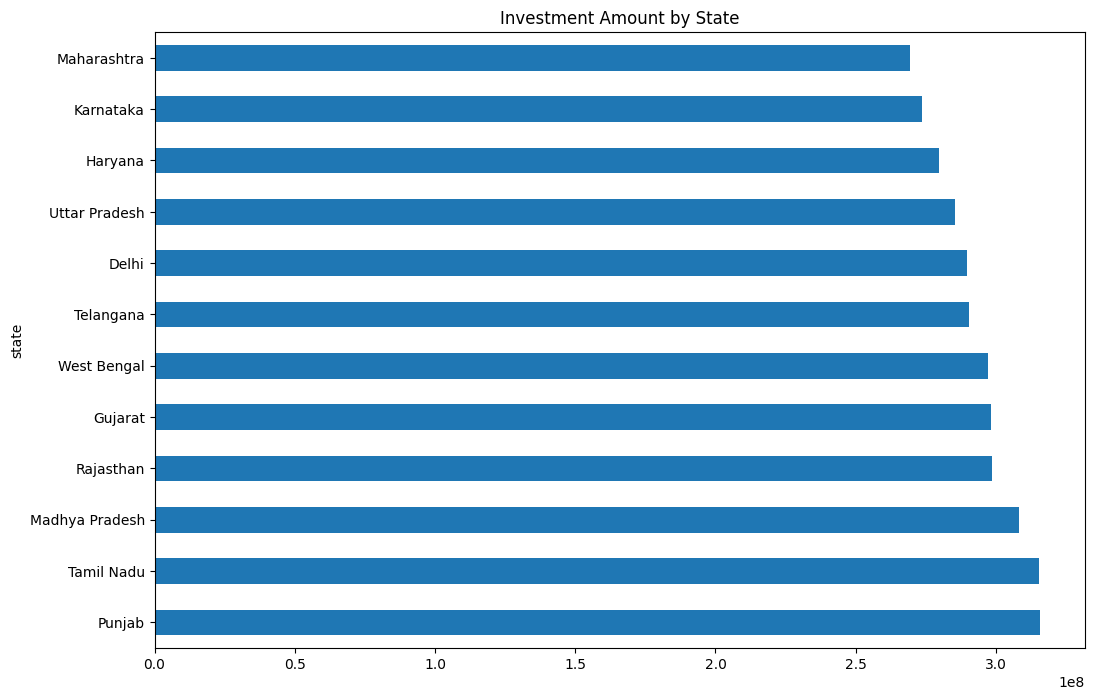

In [31]:
state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("Investment Amount by State")
plt.show()

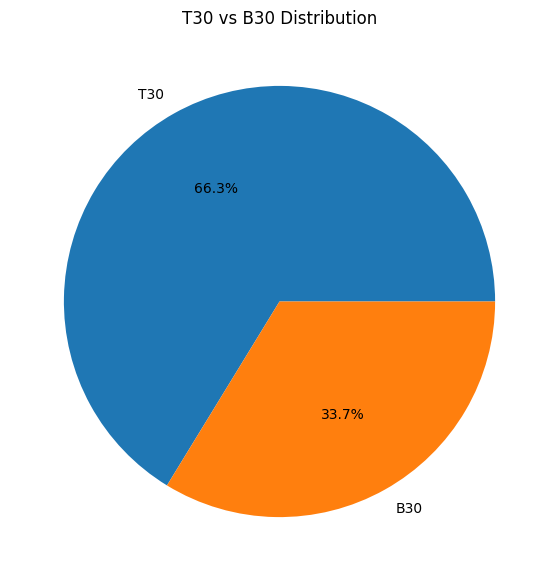

In [32]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.show()

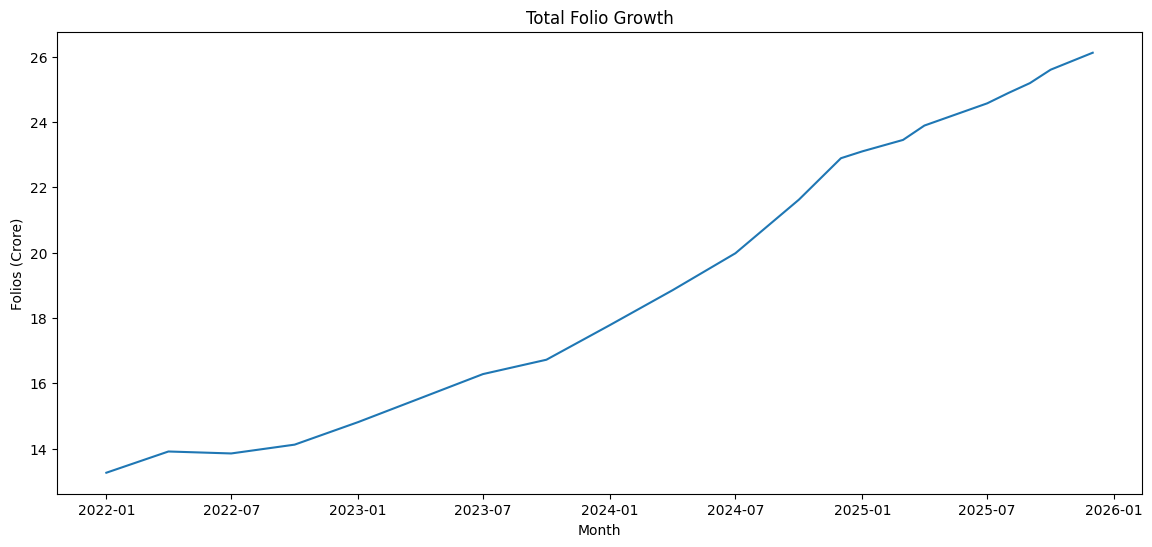

In [33]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(14,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title("Total Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.show()

In [34]:
selected = nav_history[
    nav_history["amfi_code"].isin(
        nav_history["amfi_code"].unique()[:10]
    )
]

In [35]:
pivot_df = selected.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [36]:
returns = pivot_df.pct_change()

corr_matrix = returns.corr()

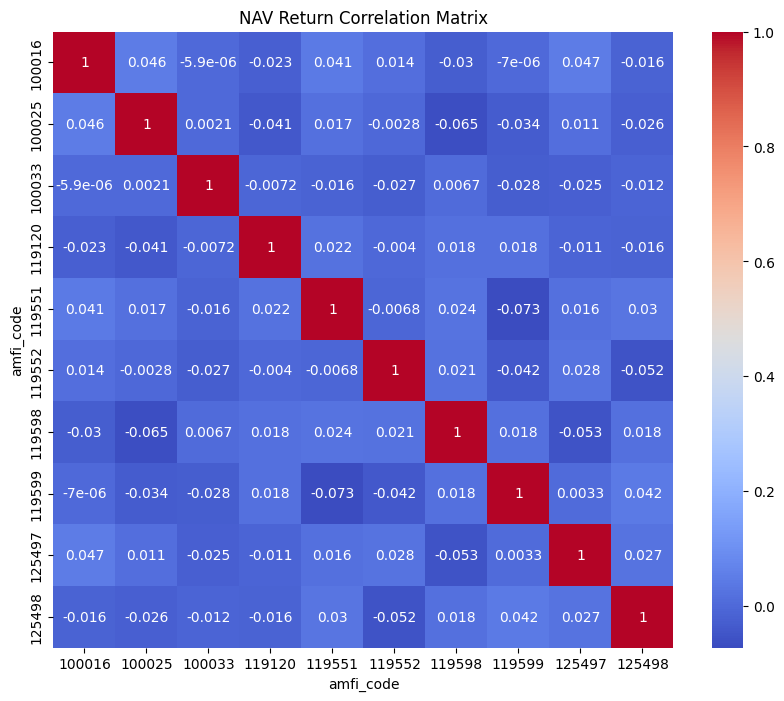

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

In [38]:
sector_weights = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

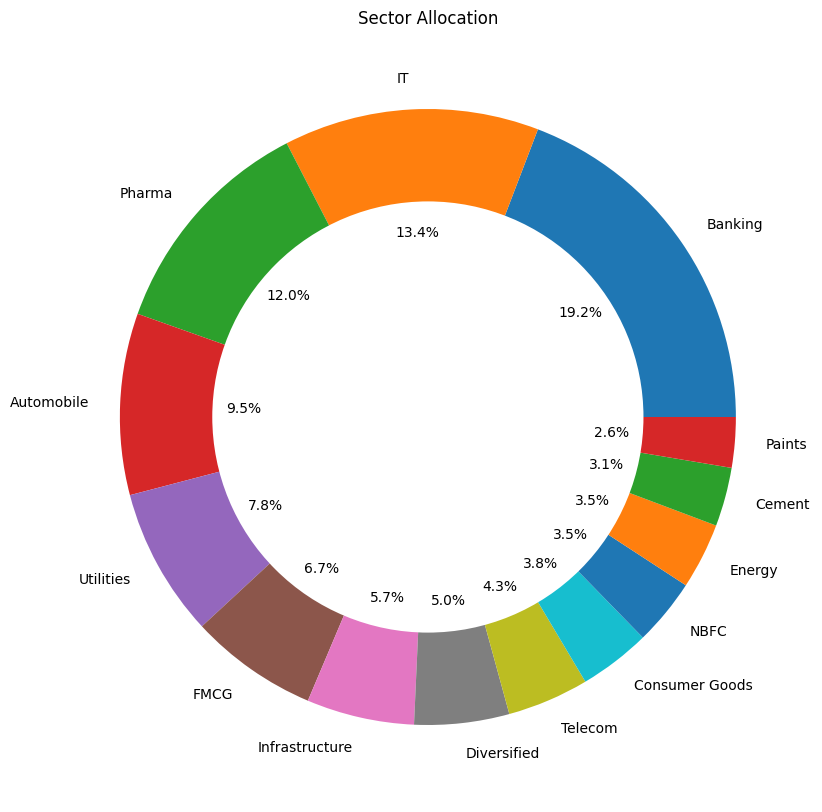

In [39]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title("Sector Allocation")
plt.show()

Insight 1:
NAVs showed a strong upward trend during 2023, indicating a broad-based market rally.

Insight 2:
SIP inflows reached an all-time high in Dec 2025, reflecting strong retail participation.

Insight 3:
SBI Mutual Fund maintained the highest AUM among all fund houses.

Insight 4:
Equity-oriented categories attracted the highest inflows.

Insight 5:
The 25–35 age group contributed the largest share of investments.

Insight 6:
Verified KYC investors accounted for more than 90% of transactions.

Insight 7:
T30 cities generated the majority of transaction volume.

Insight 8:
Total folios nearly doubled between 2022 and 2025.

Insight 9:
Several large-cap funds showed strong positive return correlations.

Insight 10:
Financial Services and IT dominated portfolio allocations.

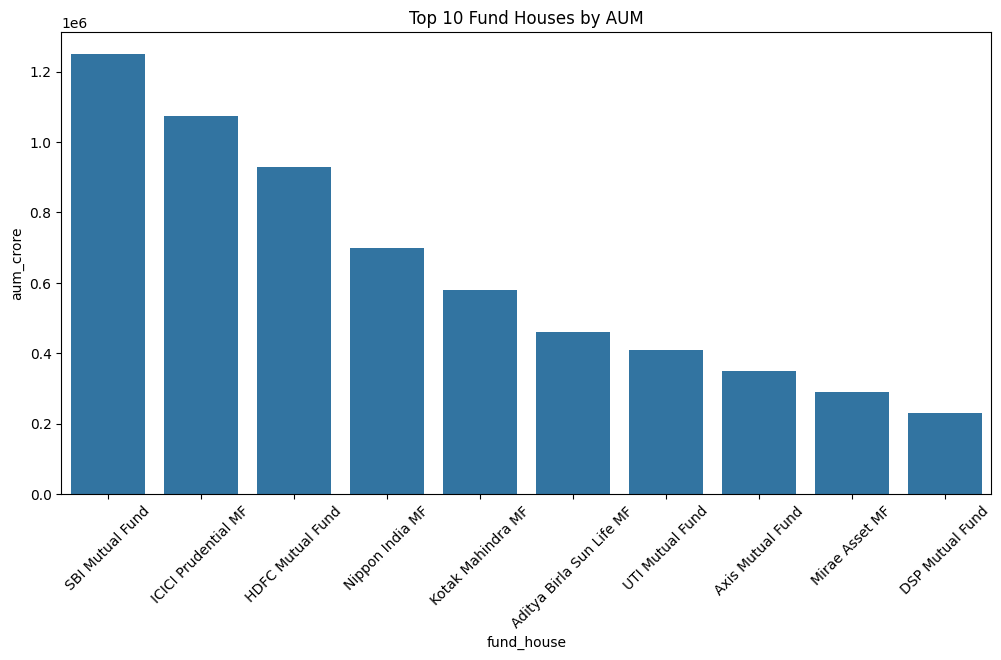

In [40]:
latest_aum = aum.sort_values("date").groupby("fund_house").tail(1)

top_aum = latest_aum.sort_values(
    "aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=45)

plt.title("Top 10 Fund Houses by AUM")

plt.show()

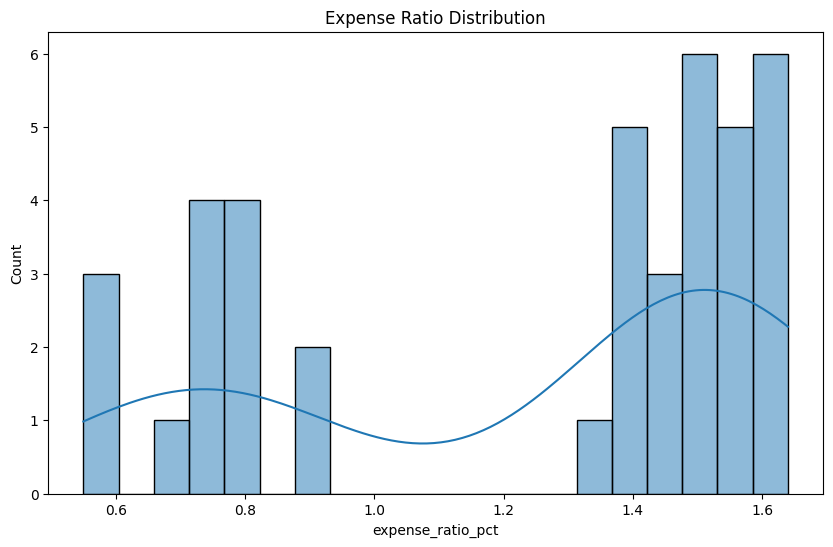

In [41]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

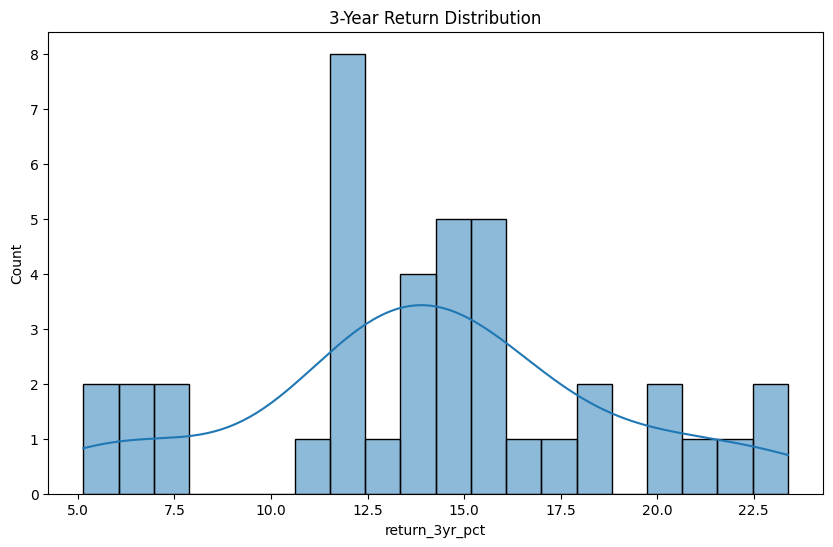

In [42]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["return_3yr_pct"],
    bins=20,
    kde=True
)

plt.title("3-Year Return Distribution")

plt.show()

In [43]:
plt.savefig(
    "../reports/chart_name.png",
    bbox_inches="tight",
    dpi=300
)

<Figure size 640x480 with 0 Axes>

In [44]:
plt.savefig("../reports/category_heatmap.png", dpi=300)
plt.savefig("../reports/age_distribution.png", dpi=300)
plt.savefig("../reports/gender_split.png", dpi=300)
plt.savefig("../reports/folio_growth.png", dpi=300)

<Figure size 640x480 with 0 Axes>